# Week 1 — Data Loading, Cleaning & EDA

**Project:** AI-Powered Fake News Detection Using Text Classification  
**Phase:** 1 of 4 (Days 1–7)  
**Notebook:** week1_data_eda.ipynb

This notebook covers:
- Loading `Fake.csv` and `True.csv` from `data/raw/`
- Merging and labelling the dataset
- Basic data quality checks
- Manual text cleaning and tokenization
- EDA: class balance, article length distribution, most frequent words
- Saving the cleaned dataset to `data/processed/`

In [1]:
import sys
import os
from pathlib import Path
PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT) 
print(f"Working directory: {PROJECT_ROOT}")

Working directory: /Users/anandkrishnagrnair/Documents/antigravity/keen-goodall/fake-news-detection


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.utils import check_raw_data, ensure_dirs
from src.preprocessing import clean_text, tokenize, build_corpus, strip_reuters_dateline

ensure_dirs("data/processed", "results/figures", "results/metrics", "results/notebook_exports")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Load Raw Data

In [3]:
fake_path, true_path = check_raw_data("data/raw")

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print(f"Fake articles: {len(fake_df):,}")
print(f"Real articles: {len(true_df):,}")
print(f"Total:         {len(fake_df) + len(true_df):,}")

Fake articles: 23,481
Real articles: 21,417
Total:         44,898


In [4]:
print("Fake.csv columns:", fake_df.columns.tolist())
print("True.csv columns:", true_df.columns.tolist())
print()
print("Fake.csv — first 2 rows:")
display(fake_df.head(2))
print("True.csv — first 2 rows:")
display(true_df.head(2))

Fake.csv columns: ['title', 'text', 'subject', 'date']
True.csv columns: ['title', 'text', 'subject', 'date']

Fake.csv — first 2 rows:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"


True.csv — first 2 rows:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"


## 2. Merge and Label

In [5]:
fake_df["label"] = 0  # 0 = fake
true_df["label"] = 1  # 1 = real

df = pd.concat([fake_df, true_df], ignore_index=True)

# Combine title and body into one text field for classification.
# Some articles have an empty/null text field — fallback to title only.
df["text"] = df["text"].fillna("").apply(strip_reuters_dateline)
df["text"] = df["title"].fillna("") + " " + df["text"]
df["text"] = df["text"].str.strip()

print(f"Merged dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Merged dataset shape: (44898, 5)
Columns: ['title', 'text', 'subject', 'date', 'label']


## 3. Data Quality Checks

In [6]:
print("Null counts per column:")
print(df.isnull().sum())
print()

n_dupes = df.duplicated(subset="text").sum()
print(f"Duplicate rows (by text): {n_dupes}")

if n_dupes > 0:
    df = df.drop_duplicates(subset="text").reset_index(drop=True)
    print(f"After deduplication: {len(df):,} rows")

Null counts per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64



Duplicate rows (by text): 5795


After deduplication: 39,103 rows


In [7]:
# Drop rows where the combined text field is effectively empty.
empty_mask = df["text"].str.strip().eq("")
print(f"Rows with empty text: {empty_mask.sum()}")
df = df[~empty_mask].reset_index(drop=True)
print(f"Dataset after empty-text removal: {len(df):,} rows")

Rows with empty text: 0
Dataset after empty-text removal: 39,103 rows


## 4. EDA — Class Balance

Class distribution:
  Fake (0): 17,907 (45.8%)
  Real (1): 21,196 (54.2%)


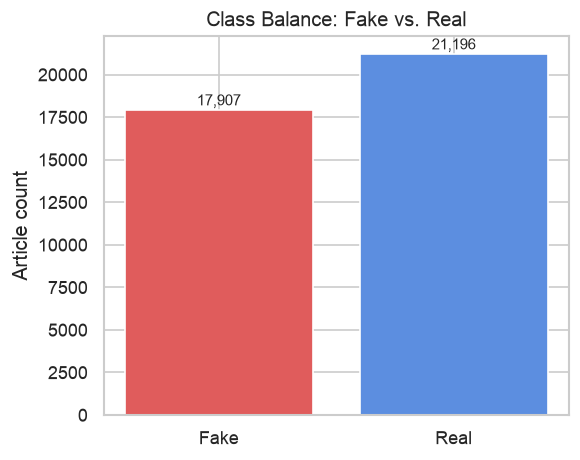

Saved: results/figures/class_balance.png


In [8]:
class_counts = df["label"].value_counts()
print("Class distribution:")
print(f"  Fake (0): {class_counts[0]:,} ({100 * class_counts[0] / len(df):.1f}%)")
print(f"  Real (1): {class_counts[1]:,} ({100 * class_counts[1] / len(df):.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Fake", "Real"], [class_counts[0], class_counts[1]], color=["#e05c5c", "#5c8ee0"])
ax.set_ylabel("Article count")
ax.set_title("Class Balance: Fake vs. Real")
for i, v in enumerate([class_counts[0], class_counts[1]]):
    ax.text(i, v + 100, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("results/figures/class_balance.png", dpi=150)
plt.show()
print("Saved: results/figures/class_balance.png")

## 5. EDA — Article Length Distribution

Word count stats (raw text):
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      17907.0  428.9  357.0  2.0  279.0  385.0  514.0  8148.0
1      21196.0  394.8  273.8  4.0  157.8  368.5  533.0  5181.0


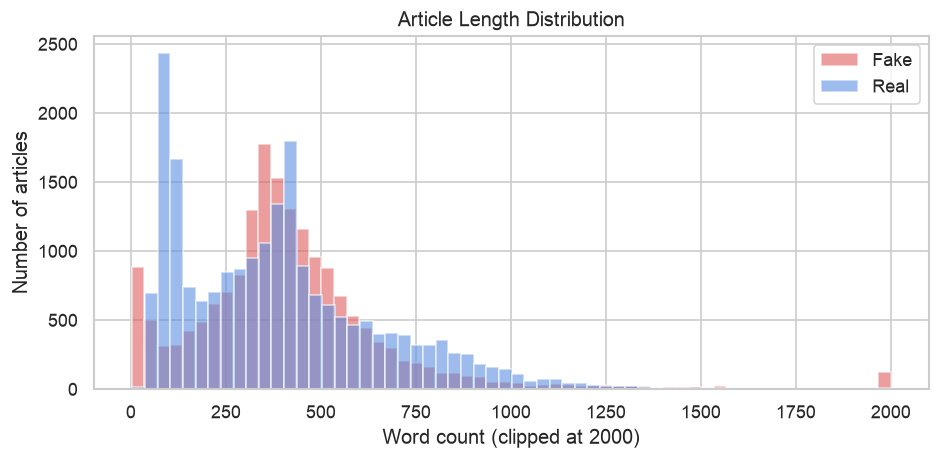

Saved: results/figures/length_distribution.png


In [9]:
# Word count before cleaning, using simple whitespace split.
df["word_count_raw"] = df["text"].str.split().apply(len)

print("Word count stats (raw text):")
print(df.groupby("label")["word_count_raw"].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, "#e05c5c", "Fake"), (1, "#5c8ee0", "Real")]:
    subset = df[df["label"] == label]["word_count_raw"]
    ax.hist(subset.clip(upper=2000), bins=60, alpha=0.6, color=color, label=name)
ax.set_xlabel("Word count (clipped at 2000)")
ax.set_ylabel("Number of articles")
ax.set_title("Article Length Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("results/figures/length_distribution.png", dpi=150)
plt.show()
print("Saved: results/figures/length_distribution.png")

## 6. Text Cleaning (Manual Tokenization)

In [10]:
# Show a before/after example on one article.
sample_raw = df.loc[0, "text"]
sample_clean = clean_text(sample_raw)

print("=== RAW (first 400 chars) ===")
print(sample_raw[:400])
print()
print("=== CLEANED (first 400 chars) ===")
print(sample_clean[:400])

=== RAW (first 400 chars) ===
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to

=== CLEANED (first 400 chars) ===
donald trump sends embarrassing new year eve message disturbing donald trump wish americans happy new year leave instead give shout enemies haters dishonest fake news media former reality show star one job country rapidly grows stronger smarter want wish friends supporters enemies haters even dishonest fake news media happy healthy new year president angry pants tweeted great year america country 


In [11]:
print("Cleaning full corpus — this may take a minute...")
df["clean_text"] = build_corpus(df, text_col="text")

# Word count after cleaning (after stopword removal and token filtering).
df["word_count_clean"] = df["clean_text"].str.split().apply(len)
print("Done.")
print()
print("Word count stats (cleaned text):")
print(df.groupby("label")["word_count_clean"].describe().round(1))

Cleaning full corpus — this may take a minute...


Done.

Word count stats (cleaned text):
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      17907.0  238.6  204.2  0.0  156.0  213.0  282.5  4961.0
1      21196.0  234.2  159.1  4.0   95.0  218.0  314.0  2360.0


In [12]:
# Drop rows where cleaning left an empty string (very rare — mostly image-only articles).
empty_after_clean = df["clean_text"].str.strip().eq("")
print(f"Empty after cleaning: {empty_after_clean.sum()}")
df = df[~empty_after_clean].reset_index(drop=True)
print(f"Final dataset size: {len(df):,} rows")

Empty after cleaning: 5
Final dataset size: 39,098 rows


## 7. EDA — Most Frequent Words per Class

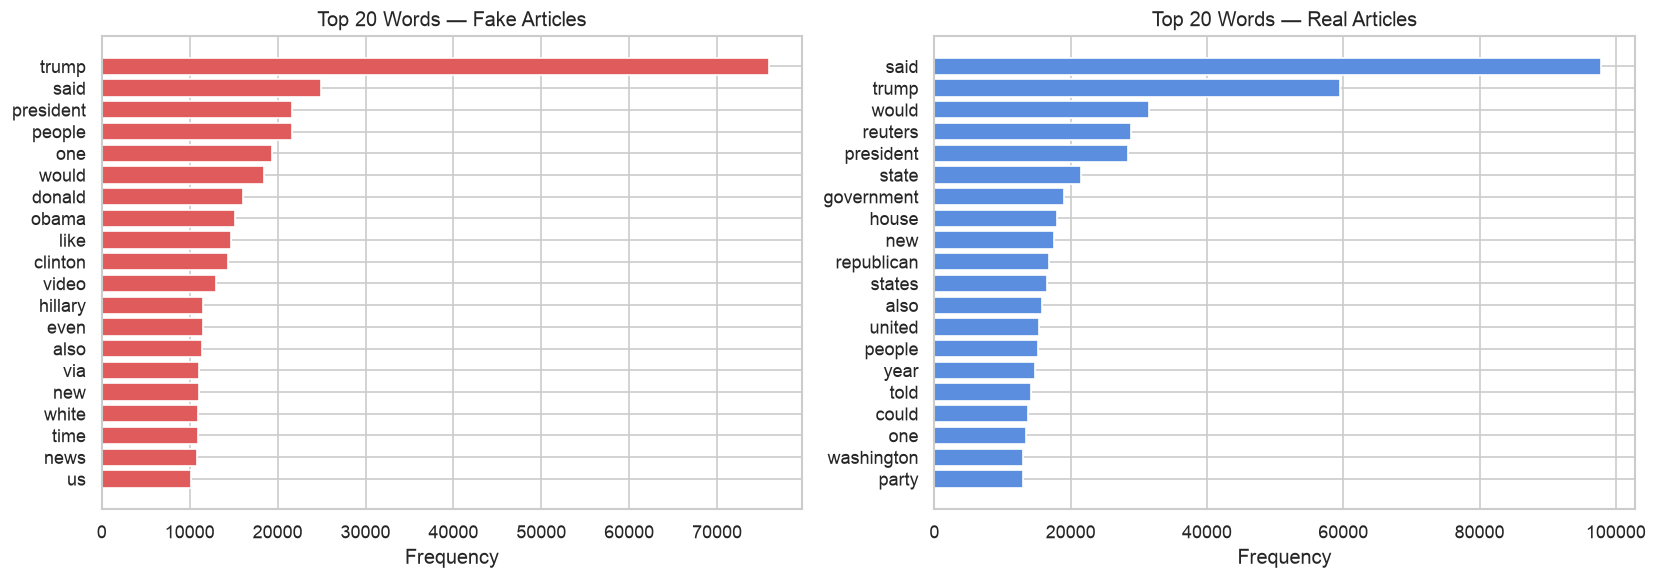

Saved: results/figures/top_words_per_class.png


In [13]:
def top_words(df_subset: pd.Series, n: int = 20) -> list:
    all_tokens = []
    for text in df_subset:
        all_tokens.extend(text.split())
    return Counter(all_tokens).most_common(n)

fake_top = top_words(df[df["label"] == 0]["clean_text"])
real_top = top_words(df[df["label"] == 1]["clean_text"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, top, title, color in [
    (axes[0], fake_top, "Top 20 Words — Fake Articles", "#e05c5c"),
    (axes[1], real_top, "Top 20 Words — Real Articles", "#5c8ee0"),
]:
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("results/figures/top_words_per_class.png", dpi=150)
plt.show()
print("Saved: results/figures/top_words_per_class.png")

## 8. Save Processed Dataset

In [14]:
# Keep only the columns needed for downstream phases.
out_cols = ["text", "clean_text", "label", "subject"] if "subject" in df.columns else ["text", "clean_text", "label"]
df[out_cols].to_csv("data/processed/news_cleaned.csv", index=False)
print(f"Saved cleaned dataset: data/processed/news_cleaned.csv ({len(df):,} rows)")

Saved cleaned dataset: data/processed/news_cleaned.csv (39,098 rows)


## 9. Subject Category Distribution (if available)

Subject distribution across full dataset:
subject
politicsNews       11216
worldnews           9980
News                9050
politics            6832
US_News              783
left-news            705
Government News      532
Name: count, dtype: int64



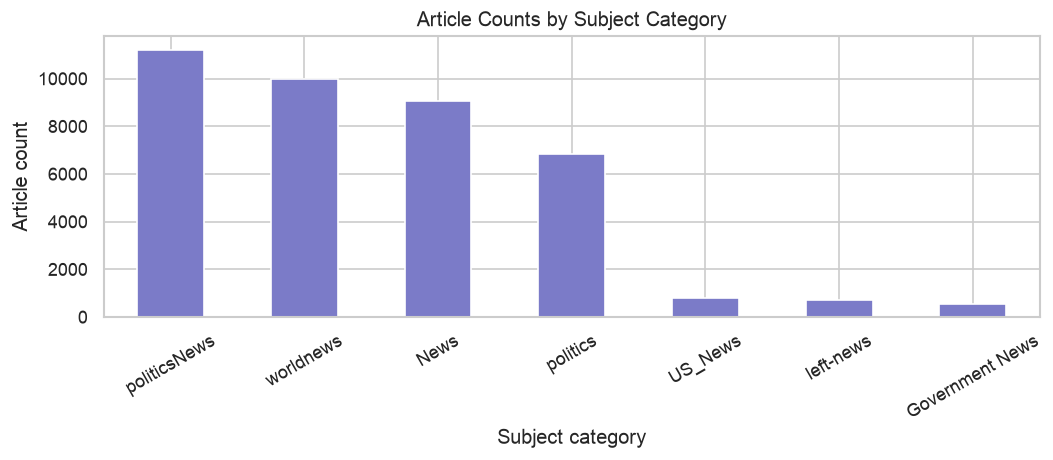

Saved: results/figures/subject_distribution.png


In [15]:
if "subject" in df.columns:
    print("Subject distribution across full dataset:")
    print(df["subject"].value_counts())
    print()

    fig, ax = plt.subplots(figsize=(9, 4))
    df["subject"].value_counts().plot(kind="bar", ax=ax, color="#7b7bc8")
    ax.set_xlabel("Subject category")
    ax.set_ylabel("Article count")
    ax.set_title("Article Counts by Subject Category")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig("results/figures/subject_distribution.png", dpi=150)
    plt.show()
    print("Saved: results/figures/subject_distribution.png")
else:
    print("No 'subject' column found in this dataset version — skipping subject EDA.")

## 10. Phase 1 Summary

Print a concise summary of everything computed above — these numbers go directly into `docs/phase1_data_report.md`.

In [16]:
print("=" * 50)
print("PHASE 1 SUMMARY")
print("=" * 50)
print(f"  Raw fake articles:         {len(fake_df):,}")
print(f"  Raw real articles:         {len(true_df):,}")
print(f"  Total after merge:         {len(fake_df) + len(true_df):,}")
print(f"  After deduplication:       {len(df):,}")
print(f"  Class balance (fake):      {100 * (df['label']==0).sum() / len(df):.1f}%")
print(f"  Class balance (real):      {100 * (df['label']==1).sum() / len(df):.1f}%")
print(f"  Avg words/article (raw):   {df['word_count_raw'].mean():.0f}")
print(f"  Avg words/article (clean): {df['word_count_clean'].mean():.0f}")
print("=" * 50)
print()
print("Figures saved to results/figures/")
print("Cleaned data saved to data/processed/news_cleaned.csv")

PHASE 1 SUMMARY
  Raw fake articles:         23,481
  Raw real articles:         21,417
  Total after merge:         44,898
  After deduplication:       39,098
  Class balance (fake):      45.8%
  Class balance (real):      54.2%
  Avg words/article (raw):   411
  Avg words/article (clean): 236

Figures saved to results/figures/
Cleaned data saved to data/processed/news_cleaned.csv
